# PINN for steady 2D laminar flow around a circular particle (Re=20) (Paper Implementation)
Paper: https://doi.org/10.3390/mca28050102


In [5]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)



Using device: cuda


In [6]:
Re        = 20.0
U_max     = 1.0               # max inlet velocity
rho       = 1.0
D         = 1.0               # diameter (characteristic length)
mu        = rho * U_max * D / Re
r         = 0.5               # radius
xc, yc    = 0.0, 0.0
x_min, x_max = -2.0, 6.0
y_min, y_max = -2.0, 2.0
H         = y_max - y_min


In [7]:
class PINN(nn.Module):
    def __init__(self, hidden_dim=64):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),      # input: x, y
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 3)       # output: u, v, p
        )

    def forward(self, xy):
        return self.net(xy)


In [8]:
def get_training_data(N_coll=20000, N_bc=8000):
    # Collocation points (inside fluid domain — exclude inside circle)
    N_attempts = N_coll * 5
    x = np.random.uniform(x_min, x_max, N_attempts)
    y = np.random.uniform(y_min, y_max, N_attempts)
    dist = np.sqrt((x - xc)**2 + (y - yc)**2)
    mask = dist > r

    x_coll = torch.tensor(x[mask][:N_coll], dtype=torch.float32, requires_grad=True).unsqueeze(1)
    y_coll = torch.tensor(y[mask][:N_coll], dtype=torch.float32, requires_grad=True).unsqueeze(1)
    xy_coll = torch.cat([x_coll, y_coll], dim=1).to(device)

    # Inlet (x = x_min) — parabolic profile
    N_inlet = N_bc // 4
    y_in = torch.linspace(y_min, y_max, N_inlet).unsqueeze(1)
    x_in = torch.full_like(y_in, x_min)
    xy_inlet = torch.cat([x_in, y_in], dim=1).to(device)

    # Outlet (x = x_max) — soft p=0
    N_out = N_bc // 4
    y_out = torch.linspace(y_min, y_max, N_out).unsqueeze(1)
    x_out = torch.full_like(y_out, x_max)
    xy_outlet = torch.cat([x_out, y_out], dim=1).to(device)

    # Walls (top/bottom + cylinder) — u=0, v=0
    N_wall_tb = N_bc // 4
    N_cyl = N_bc // 2

    # top/bottom
    x_tb = torch.rand(N_wall_tb, 1) * (x_max - x_min) + x_min
    X_top    = torch.cat([x_tb[:N_wall_tb//2], torch.full_like(x_tb[:N_wall_tb//2], y_max)], dim=1).to(device)
    X_bottom = torch.cat([x_tb[N_wall_tb//2:], torch.full_like(x_tb[N_wall_tb//2:], y_min)], dim=1).to(device)

    # cylinder surface
    theta = torch.rand(N_cyl, 1) * 2 * np.pi
    X_cyl = torch.cat([
        torch.full_like(theta, xc) + r * torch.cos(theta),
        torch.full_like(theta, yc) + r * torch.sin(theta)
    ], dim=1).to(device)

    xy_wall = torch.cat([X_top, X_bottom, X_cyl], dim=0)

    return xy_coll, xy_inlet, xy_outlet, xy_wall

In [9]:
def compute_physics_loss(model, xy):
    xy = xy.clone().detach().requires_grad_(True)
    uvp = model(xy)
    u, v, p = uvp[:,0:1], uvp[:,1:2], uvp[:,2:3]

    # First derivatives
    du = torch.autograd.grad(u.sum(), xy, create_graph=True)[0]
    dv = torch.autograd.grad(v.sum(), xy, create_graph=True)[0]
    dp = torch.autograd.grad(p.sum(), xy, create_graph=True)[0]

    u_x, u_y = du[:,0:1], du[:,1:2]
    v_x, v_y = dv[:,0:1], dv[:,1:2]
    p_x, p_y = dp[:,0:1], dp[:,1:2]

    # Second derivatives
    u_xx = torch.autograd.grad(u_x.sum(), xy, create_graph=True)[0][:,0:1]
    u_yy = torch.autograd.grad(u_y.sum(), xy, create_graph=True)[0][:,1:2]
    v_xx = torch.autograd.grad(v_x.sum(), xy, create_graph=True)[0][:,0:1]
    v_yy = torch.autograd.grad(v_y.sum(), xy, create_graph=True)[0][:,1:2]

    continuity = u_x + v_y

    mom_x = rho * (u * u_x + v * u_y) + p_x - mu * (u_xx + u_yy)
    mom_y = rho * (u * v_x + v * v_y) + p_y - mu * (v_xx + v_yy)

    loss_pde = (continuity**2 + mom_x**2 + mom_y**2).mean()
    return loss_pde

In [10]:
def compute_bc_losses(model, xy_inlet, xy_outlet, xy_wall):
    # Inlet: parabolic u, v=0
    pred_in = model(xy_inlet)
    u_in, v_in = pred_in[:,0], pred_in[:,1]

    y = xy_inlet[:,1]
    u_target = 4 * U_max * (y - y_min) * (y_max - y) / H**2
    v_target = torch.zeros_like(y)

    loss_inlet = ((u_in - u_target)**2 + (v_in - v_target)**2).mean()

    # Outlet: p ≈ 0 (soft)
    pred_out = model(xy_outlet)
    p_out = pred_out[:,2]
    loss_outlet = (p_out**2).mean()

    # Walls & cylinder: u=0, v=0
    pred_wall = model(xy_wall)
    u_wall, v_wall = pred_wall[:,0], pred_wall[:,1]
    loss_wall = (u_wall**2 + v_wall**2).mean()

    return loss_inlet, loss_outlet, loss_wall

In [11]:
xy_coll, xy_inlet, xy_outlet, xy_wall = get_training_data()

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 8000

for epoch in range(epochs):
    optimizer.zero_grad()

    loss_pde    = compute_physics_loss(model, xy_coll)
    loss_inlet, loss_outlet, loss_wall = compute_bc_losses(model, xy_inlet, xy_outlet, xy_wall)

    # Weights (tuned empirically — similar to paper practice)
    w_pde    = 1.0
    w_inlet  = 5.0
    w_outlet = 2.0
    w_wall   = 10.0

    loss = w_pde * loss_pde + w_inlet * loss_inlet + w_outlet * loss_outlet + w_wall * loss_wall

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Total: {loss.item():.5e} | "
              f"PDE: {loss_pde.item():.2e} | Inlet: {loss_inlet.item():.2e} | "
              f"Outlet: {loss_outlet.item():.2e} | Wall: {loss_wall.item():.2e}")

print("Training finished.")

# Optional: save model
torch.save(model.state_dict(), "particle_flow_pinn.pth")


Epoch     0 | Total: 3.67508e+00 | PDE: 3.08e-03 | Inlet: 6.93e-01 | Outlet: 1.61e-03 | Wall: 2.02e-02
Epoch   500 | Total: 4.02139e-02 | PDE: 3.51e-02 | Inlet: 3.03e-04 | Outlet: 3.24e-06 | Wall: 3.61e-04
Epoch  1000 | Total: 2.91898e-02 | PDE: 2.54e-02 | Inlet: 1.37e-04 | Outlet: 2.01e-07 | Wall: 3.12e-04
Epoch  1500 | Total: 2.56632e-02 | PDE: 2.25e-02 | Inlet: 1.15e-04 | Outlet: 1.30e-07 | Wall: 2.62e-04
Epoch  2000 | Total: 2.38237e-02 | PDE: 2.09e-02 | Inlet: 1.74e-04 | Outlet: 4.43e-07 | Wall: 2.09e-04
Epoch  2500 | Total: 2.18446e-02 | PDE: 1.99e-02 | Inlet: 8.00e-05 | Outlet: 6.92e-07 | Wall: 1.59e-04
Epoch  3000 | Total: 2.02713e-02 | PDE: 1.86e-02 | Inlet: 7.91e-05 | Outlet: 3.21e-07 | Wall: 1.25e-04
Epoch  3500 | Total: 1.89227e-02 | PDE: 1.74e-02 | Inlet: 9.52e-05 | Outlet: 4.17e-07 | Wall: 1.02e-04
Epoch  4000 | Total: 1.81528e-02 | PDE: 1.64e-02 | Inlet: 8.49e-05 | Outlet: 2.73e-06 | Wall: 1.29e-04
Epoch  4500 | Total: 1.81215e-02 | PDE: 1.53e-02 | Inlet: 3.24e-04 | Outl

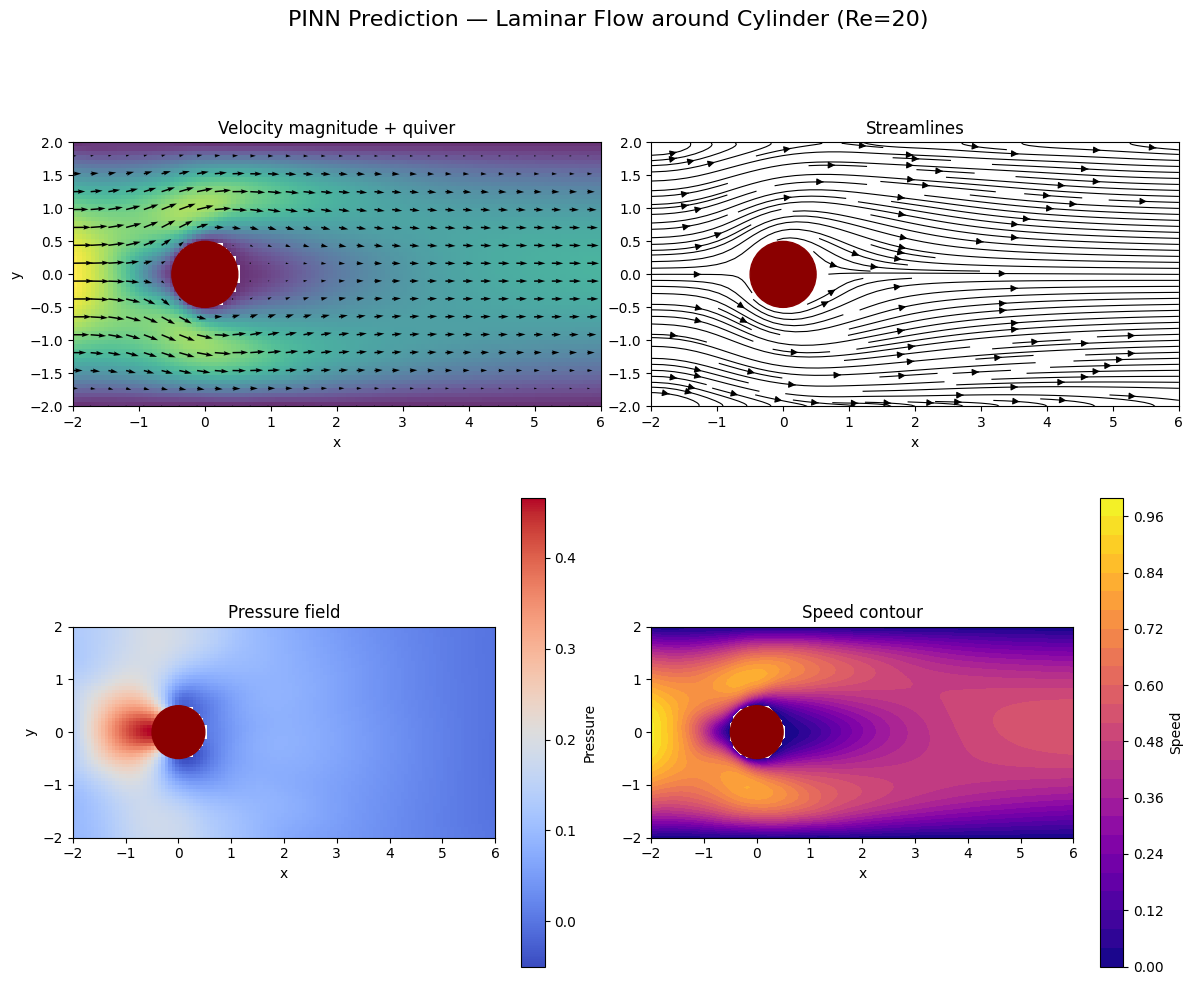

In [12]:
@torch.no_grad()
def plot_comparison():
    nx, ny = 120, 60                  # nx = x-points, ny = y-points

    x = np.linspace(x_min, x_max, nx)
    y = np.linspace(y_min, y_max, ny)

    # meshgrid returns (ny, nx) shape → rows=y, columns=x
    X, Y = np.meshgrid(x, y)          # X.shape = Y.shape = (ny, nx) = (60, 120)

    # Flatten for model input
    xy_grid = torch.tensor(np.c_[X.ravel(), Y.ravel()], dtype=torch.float32).to(device)

    # Predict → shape (nx*ny, 3)
    pred = model(xy_grid).cpu().numpy()

    # Reshape to match meshgrid order: (ny, nx)
    u = pred[:, 0].reshape(ny, nx)
    v = pred[:, 1].reshape(ny, nx)
    p = pred[:, 2].reshape(ny, nx)

    # Mask: same shape as u/v/p → (ny, nx)
    dist = np.sqrt((X - xc)**2 + (Y - yc)**2)
    inside = dist <= r

    # Apply mask (now shapes match perfectly)
    u[inside] = np.nan
    v[inside] = np.nan
    p[inside] = np.nan

    speed = np.sqrt(u**2 + v**2)

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle("PINN Prediction — Laminar Flow around Cylinder (Re=20)", fontsize=16)

    # Velocity magnitude + quiver
    axs[0,0].imshow(speed, extent=[x_min, x_max, y_min, y_max],
                    origin='lower', cmap='viridis', alpha=0.8)
    # Subsample quiver to avoid clutter
    axs[0,0].quiver(X[::4, ::4], Y[::4, ::4],
                    u[::4, ::4], v[::4, ::4], scale=25, color='black')
    axs[0,0].add_patch(plt.Circle((xc, yc), r, color='darkred', zorder=10))
    axs[0,0].set_title("Velocity magnitude + quiver")
    axs[0,0].set_aspect('equal')
    axs[0,0].set_xlabel('x')
    axs[0,0].set_ylabel('y')

    # Streamlines
    axs[0,1].streamplot(X, Y, u, v, color='black', density=1.5, linewidth=0.8)
    axs[0,1].add_patch(plt.Circle((xc, yc), r, color='darkred', zorder=10))
    axs[0,1].set_title("Streamlines")
    axs[0,1].set_aspect('equal')
    axs[0,1].set_xlabel('x')

    # Pressure field
    im = axs[1,0].imshow(p, extent=[x_min, x_max, y_min, y_max],
                         origin='lower', cmap='coolwarm')
    axs[1,0].add_patch(plt.Circle((xc, yc), r, color='darkred', zorder=10))
    axs[1,0].set_title("Pressure field")
    axs[1,0].set_aspect('equal')
    axs[1,0].set_xlabel('x')
    axs[1,0].set_ylabel('y')
    fig.colorbar(im, ax=axs[1,0], label='Pressure')

    # Speed contour
    cs = axs[1,1].contourf(X, Y, speed, levels=30, cmap='plasma')
    axs[1,1].add_patch(plt.Circle((xc, yc), r, color='darkred', zorder=10))
    axs[1,1].set_title("Speed contour")
    axs[1,1].set_aspect('equal')
    axs[1,1].set_xlabel('x')
    fig.colorbar(cs, ax=axs[1,1], label='Speed')

    plt.tight_layout()
    plt.show()

plot_comparison()